In [1]:
#####################################################################################################################################
##### STEP 2: Build PPI network for genes from metabolite-gene PKN
#####
##### This script builds a PPI network for an input list of genes extracted from the metabolite-gene PKN.
##### This network will be combined with the metabolite-gene network to build an integrated gene-metabolite network.
#####
##### WORKFLOW:
#####   1. Run: Collect_PKNdata_metabolites.ipynb  (outputs: metabolite_gene_PKN.tsv)
#####   2. Run: Collect_PKNdata_proteins.ipynb     (this script - outputs: PPI_network.tsv)  
#####   3. Run: Build_final_PKN.ipynb              (combines both networks)
#####
##### IMPORTANT: Make sure OUTPUT_DIR_NAME matches the one used in Collect_PKNdata_metabolites.ipynb
#####
##### Data sources:
######### 1. STRING (via API)
######### 2. BioGRID (downloaded database)
######### 3. Human Reference Interactome (HuRI)
#####################################################################################################################################

In [5]:
# import modules and set working directory
import os
import pandas as pd
from pybiomart import Dataset
import requests
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
import mygene

# ===== CONFIGURATION - Change output directory here =====
# This should match the OUTPUT_DIR_NAME used in Collect_PKNdata_metabolites.ipynb
workdir = '/home/borisvdm/Documents/PhD/Lemonite'
OUTPUT_DIR_NAME = 'PKN'  # Change this to match metabolites script
# ========================================================

# Set up paths
OUTPUT_DIR = os.path.join(workdir, OUTPUT_DIR_NAME)
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')

# Database locations (external resources)
BIOGRID_location = '/home/borisvdm/Documents/PhD/resources/databases/BioGRID/BIOGRID-ALL-4.4.238.tab3.txt'
HuRi_location = '/home/borisvdm/Documents/PhD/resources/databases/HuRi/HuRI.tsv'
ENSEMBL_MAPPING_FILE = os.path.join(workdir, 'ensembl_mapping_jan2024.txt')

# Input file (output from metabolites script)
METABOLITE_GENE_PKN_FILE = os.path.join(OUTPUT_DIR, 'metabolite_gene_PKN.tsv')

# Output files
STRING_INTERACTIONS_FILE = os.path.join(OUTPUT_DIR, 'STRING_interactions.csv')
BIOGRID_GENES_FILE = os.path.join(OUTPUT_DIR, 'BioGRID_genes_interactions.csv')
PPI_NETWORK_FILE = os.path.join(OUTPUT_DIR, 'PPI_network.tsv')
PPI_VENN_FIGURE = os.path.join(FIGURES_DIR, 'PPI_network_overlap.png')

# Create output directories if they don't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Configuration:")
print(f"  Working directory: {workdir}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Figures directory: {FIGURES_DIR}")
print(f"  Input metabolite-gene PKN: {METABOLITE_GENE_PKN_FILE}")
print(f"  Output PPI network: {PPI_NETWORK_FILE}")

Configuration:
  Working directory: /home/borisvdm/Documents/PhD/Lemonite
  Output directory: /home/borisvdm/Documents/PhD/Lemonite/PKN
  Figures directory: /home/borisvdm/Documents/PhD/Lemonite/PKN/figures
  Input metabolite-gene PKN: /home/borisvdm/Documents/PhD/Lemonite/PKN/metabolite_gene_PKN.tsv
  Output PPI network: /home/borisvdm/Documents/PhD/Lemonite/PKN/PPI_network.tsv


In [3]:
# Read metabolite-gene PKN data (output from Collect_PKNdata_metabolites.ipynb)
print(f"Reading metabolite-gene PKN from: {METABOLITE_GENE_PKN_FILE}")
metabolite_gene_PKN = pd.read_csv(METABOLITE_GENE_PKN_FILE, sep='\t')
print(metabolite_gene_PKN)

genes = metabolite_gene_PKN['Gene'].unique()
print(f'Number of genes in the gene-metabolite PKN: {len(genes)}')

Reading metabolite-gene PKN from: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/metabolite_gene_PKN.tsv


FileNotFoundError: [Errno 2] No such file or directory: '/home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/metabolite_gene_PKN.tsv'

In [7]:
def get_string_interactions_chunk(gene_list_chunk):
    
    string_api_url = "https://version-11-5.string-db.org/api"
    output_format = "tsv-no-header"
    method = "get_string_ids"

    # Send a request to get STRING IDs for all genes in the chunk
    params = {
        "identifiers": "\r".join(gene_list_chunk),
        "species": 9606,
        "limit": 1,
        "echo_query": 1,
        "caller_identity": "LemonIte"
    }

    request_url = "/".join([string_api_url, output_format, method])
    results = requests.post(request_url, data=params)

    # Create a DataFrame to store STRING IDs
    df = pd.DataFrame(columns=['symbol', 'string_id'])
    for line in results.text.strip().split("\n"):
        l = line.split("\t")
        input_identifier, string_identifier = l[0], l[2]
        df = pd.concat([df, pd.DataFrame({'symbol': [input_identifier], 'string_id': [string_identifier]})])

    string_ids = df['string_id'].tolist()
    if not string_ids:
        print("No STRING IDs found for the input genes.")
        return pd.DataFrame()

    # Retrieve interaction partners for the entire chunk of STRING IDs
    method = "interaction_partners"
    request_url = "/".join([string_api_url, output_format, method])

    params = {
        "identifiers": "%0d".join(string_ids),  # Joining all STRING IDs in this chunk
        "species": 9606,
        "caller_identity": "LemonIte"
    }

    response = requests.post(request_url, data=params)
    string_interactions_df = pd.DataFrame(columns=['query_ensp', 'query_name', 'partner_name', 'combined_score'])

    # Parse response and store results in DataFrame
    for line in response.text.strip().split("\n"):
        l = line.strip().split("\t")
        query_ensp = l[0]
        query_name = l[2]
        # partner_ensp = l[1]
        partner_name = l[3]
        combined_score = l[5]
        string_interactions_df = pd.concat([string_interactions_df, pd.DataFrame({
            'query_ensp': [query_ensp], 'query_name': [query_name], 
            'partner_name': [partner_name], 'combined_score': [combined_score]
        })])
        
    time.sleep(1)  # Sleep for 1 second to avoid hitting the rate limit of the API

    return string_interactions_df


def get_string_interactions_parallel(gene_list, chunk_size=1000, num_workers=10):
    # Split the gene list into larger chunks based on the chunk_size parameter
    gene_chunks = [gene_list[i:i + chunk_size] for i in range(0, len(gene_list), chunk_size)]
    

    print(f'Starting parallel processing with {num_workers} workers and chunk size of {chunk_size} genes...')
    print(f'Total number of chunks: {len(gene_chunks)}')
    
    # Use ThreadPoolExecutor to parallelize the requests
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = {executor.submit(get_string_interactions_chunk, chunk): i for i, chunk in enumerate(gene_chunks)}

        results = []
        for future in as_completed(futures):
            chunk_index = futures[future]
            try:
                result = future.result()
                print(f"Chunk {chunk_index + 1} of {len(gene_chunks)} completed.")
                results.append(result)
            except Exception as e:
                print(f"Error occurred in chunk {chunk_index + 1}: {e}")

    # Combine the results into a single DataFrame
    final_df = pd.concat(results, ignore_index=True)
    print("All chunks completed.")
    return final_df

# Example usage

chunk_size = 1000  # Set the chunk size larger for larger batches
string_interactions_df = get_string_interactions_parallel(genes, chunk_size=chunk_size, num_workers=10)

# write interactions to csv file
string_interactions_df.to_csv(STRING_INTERACTIONS_FILE, index=False)
print(f'Saved STRING interactions to: {STRING_INTERACTIONS_FILE}')

Starting parallel processing with 10 workers and chunk size of 1000 genes...
Total number of chunks: 17
Chunk 8 of 17 completed.
Chunk 8 of 17 completed.
Chunk 5 of 17 completed.
Chunk 5 of 17 completed.
Chunk 7 of 17 completed.
Chunk 7 of 17 completed.
Chunk 3 of 17 completed.
Chunk 3 of 17 completed.
Chunk 4 of 17 completed.
Chunk 4 of 17 completed.
Chunk 2 of 17 completed.
Chunk 2 of 17 completed.
Chunk 1 of 17 completed.
Chunk 1 of 17 completed.
Chunk 9 of 17 completed.
Chunk 9 of 17 completed.
Chunk 17 of 17 completed.
Chunk 17 of 17 completed.
Chunk 10 of 17 completed.
Chunk 10 of 17 completed.
Chunk 6 of 17 completed.
Chunk 6 of 17 completed.
Chunk 12 of 17 completed.
Chunk 12 of 17 completed.
Chunk 16 of 17 completed.
Chunk 16 of 17 completed.
Chunk 15 of 17 completed.
Chunk 15 of 17 completed.
Chunk 11 of 17 completed.
Chunk 11 of 17 completed.
Chunk 14 of 17 completed.
Chunk 14 of 17 completed.
Chunk 13 of 17 completed.
All chunks completed.
Chunk 13 of 17 completed.
All chun

In [8]:
#string_interactions_df = pd.read_csv(STRING_INTERACTIONS_FILE)
string_interactions_df

,query_ensp,query_name,partner_name,combined_score
0,9606.ENSP00000001146,CYP26B1,ALDH1A2,0.981
1,9606.ENSP00000001146,CYP26B1,ALDH1A3,0.975
2,9606.ENSP00000001146,CYP26B1,ALDH1A1,0.962
3,9606.ENSP00000001146,CYP26B1,CRABP1,0.958
4,9606.ENSP00000001146,CYP26B1,CYP2B6,0.935
...,...,...,...,...
1585198,9606.ENSP00000480637,MAGEA6,MORN3,0.414
1585199,9606.ENSP00000480637,MAGEA6,OR10K1,0.414
1585200,9606.ENSP00000480637,MAGEA6,CLPSL1,0.412
1585201,9606.ENSP00000480637,MAGEA6,C4orf51,0.403


In [9]:
print(string_interactions_df)

                   query_ensp query_name partner_name combined_score
0        9606.ENSP00000001146    CYP26B1      ALDH1A2          0.981
1        9606.ENSP00000001146    CYP26B1      ALDH1A3          0.975
2        9606.ENSP00000001146    CYP26B1      ALDH1A1          0.962
3        9606.ENSP00000001146    CYP26B1       CRABP1          0.958
4        9606.ENSP00000001146    CYP26B1       CYP2B6          0.935
...                       ...        ...          ...            ...
1585198  9606.ENSP00000480637     MAGEA6        MORN3          0.414
1585199  9606.ENSP00000480637     MAGEA6       OR10K1          0.414
1585200  9606.ENSP00000480637     MAGEA6       CLPSL1          0.412
1585201  9606.ENSP00000480637     MAGEA6      C4orf51          0.403
1585202  9606.ENSP00000480637     MAGEA6         PMEL          0.402

[1585203 rows x 4 columns]


In [10]:
print(f'There are {string_interactions_df.shape[0]} interactions in the STRING network.')
print(string_interactions_df)
# Rename columns
string_interactions_df.columns = ['query_ensp', 'GeneA', 'GeneB', 'combined_score']
# drop 'query_ensp' column
string_interactions_df = string_interactions_df.drop(columns='query_ensp')

# How many genes from GeneA and GeneB are in the input list?
genes_in_input_list = genes
string_genes = list(set(string_interactions_df['GeneA'].tolist() + string_interactions_df['GeneB'].tolist()))
print(f'There are {len(set(string_genes).intersection(genes_in_input_list))} genes in the STRING network that are in the input list.')
# How many genes from GeneA and GeneB are not in the input list?
string_genes_not_in_input_list = list(set(string_genes).difference(genes_in_input_list))
print(f'There are {len(string_genes_not_in_input_list)} genes in the STRING network that are not in the input list.')

There are 1585203 interactions in the STRING network.
                   query_ensp query_name partner_name combined_score
0        9606.ENSP00000001146    CYP26B1      ALDH1A2          0.981
1        9606.ENSP00000001146    CYP26B1      ALDH1A3          0.975
2        9606.ENSP00000001146    CYP26B1      ALDH1A1          0.962
3        9606.ENSP00000001146    CYP26B1       CRABP1          0.958
4        9606.ENSP00000001146    CYP26B1       CYP2B6          0.935
...                       ...        ...          ...            ...
1585198  9606.ENSP00000480637     MAGEA6        MORN3          0.414
1585199  9606.ENSP00000480637     MAGEA6       OR10K1          0.414
1585200  9606.ENSP00000480637     MAGEA6       CLPSL1          0.412
1585201  9606.ENSP00000480637     MAGEA6      C4orf51          0.403
1585202  9606.ENSP00000480637     MAGEA6         PMEL          0.402

[1585203 rows x 4 columns]
There are 12035 genes in the STRING network that are in the input list.
There are 7222 gen

In [11]:
# write interactions to csv file
string_interactions_df.to_csv(STRING_INTERACTIONS_FILE, index=False)
print(f'Saved STRING interactions to: {STRING_INTERACTIONS_FILE}')

Saved STRING interactions to: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/STRING_interactions.csv


In [12]:
string_interactions_df = pd.read_csv(STRING_INTERACTIONS_FILE)
string_interactions_df

,GeneA,GeneB,combined_score
0,CYP26B1,ALDH1A2,0.981
1,CYP26B1,ALDH1A3,0.975
2,CYP26B1,ALDH1A1,0.962
3,CYP26B1,CRABP1,0.958
4,CYP26B1,CYP2B6,0.935
...,...,...,...
1585198,MAGEA6,MORN3,0.414
1585199,MAGEA6,OR10K1,0.414
1585200,MAGEA6,CLPSL1,0.412
1585201,MAGEA6,C4orf51,0.403


# Rerieve interactions from BioGRID, use the downloaded database

In [13]:
# Read bioGRID data
bioGRID = pd.read_csv(BIOGRID_location, sep='\t', low_memory=False)
bioGRID

,#BioGRID Interaction ID,Entrez Gene Interactor A,Entrez Gene Interactor B,BioGRID ID Interactor A,BioGRID ID Interactor B,Systematic Name Interactor A,Systematic Name Interactor B,Official Symbol Interactor A,Official Symbol Interactor B,Synonyms Interactor A,...,TREMBL Accessions Interactor B,REFSEQ Accessions Interactor B,Ontology Term IDs,Ontology Term Names,Ontology Term Categories,Ontology Term Qualifier IDs,Ontology Term Qualifier Names,Ontology Term Types,Organism Name Interactor A,Organism Name Interactor B
0,103,6416,2318,112315,108607,-,-,MAP2K4,FLNC,JNKK|JNKK1|MAPKK4|MEK4|MKK4|PRKMK4|SAPKK-1|SAP...,...,Q59H94,NP_001120959|NP_001449,-,-,-,-,-,-,Homo sapiens,Homo sapiens
1,117,84665,88,124185,106603,-,-,MYPN,ACTN2,CMD1DD|CMH22|MYOP|RCM4,...,Q59FD9|F6THM6,NP_001094|NP_001265272|NP_001265273,-,-,-,-,-,-,Homo sapiens,Homo sapiens
2,183,90,2339,106605,108625,-,-,ACVR1,FNTA,ACTRI|ACVR1A|ACVRLK2|ALK2|FOP|SKR1|TSRI,...,-,NP_002018,-,-,-,-,-,-,Homo sapiens,Homo sapiens
3,278,2624,5371,108894,111384,-,-,GATA2,PML,DCML|IMD21|MONOMAC|NFE1B,...,-,NP_150250|NP_150253|NP_150252|NP_150247|NP_150...,-,-,-,-,-,-,Homo sapiens,Homo sapiens
4,418,6118,6774,112038,112651,RP4-547C9.3,-,RPA2,STAT3,REPA2|RP-A p32|RP-A p34|RPA32,...,-,NP_644805|NP_003141|NP_001356447|NP_001356443|...,-,-,-,-,-,-,Homo sapiens,Homo sapiens
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2721754,3738984,402682,8878,135544,114397,tcag7.1226,-,UFSP1,SQSTM1,UFSP,...,-,NP_003891|NP_001135771|NP_001135770,-,-,-,-,-,-,Homo sapiens,Homo sapiens
2721755,3738985,402682,10432,135544,115700,tcag7.1226,-,UFSP1,RBM14,UFSP,...,-,NP_001185766|NP_001185765|NP_006319,-,-,-,-,-,-,Homo sapiens,Homo sapiens
2721756,3738986,8878,8878,114397,114397,-,-,SQSTM1,SQSTM1,A170|OSIL|PDB3|ZIP3|p60|p62|p62B,...,-,NP_003891|NP_001135771|NP_001135770,-,-,-,-,-,-,Homo sapiens,Homo sapiens
2721757,3738987,8878,8878,114397,114397,-,-,SQSTM1,SQSTM1,A170|OSIL|PDB3|ZIP3|p60|p62|p62B,...,-,NP_003891|NP_001135771|NP_001135770,-,-,-,-,-,-,Homo sapiens,Homo sapiens


In [14]:
# Get a list of all 'Official Symbol Interactor A' and 'Official Symbol Interactor B' from BioGRID
bioGRID_genes = list(set(bioGRID['Official Symbol Interactor A'].tolist() + bioGRID['Official Symbol Interactor B'].tolist()))
print(f'There are {len(bioGRID_genes)} genes in the BioGRID network.')
# Subset BioGRID to only include human interactions
bioGRID = bioGRID[(bioGRID['Organism Name Interactor A'] == 'Homo sapiens') | (bioGRID['Organism Name Interactor B'] == 'Homo sapiens')]
# Select columns 'Official Symbol Interactor A' and 'Official Symbol Interactor B'
bioGRID = bioGRID[['Official Symbol Interactor A', 'Official Symbol Interactor B']]

# How many genes from bioGRID_genes are in the input list?
print(f'There are {len(set(bioGRID_genes).intersection(genes))} genes in the BioGRID network that are in the input list.')
# Select rows where one of 'Official Symbol Interactor A' and 'Official Symbol Interactor B' are in the input list
bioGRID_pruned = bioGRID[bioGRID['Official Symbol Interactor A'].isin(genes) | bioGRID['Official Symbol Interactor B'].isin(genes)]
#print(bioGRID_pruned)
# How many interactions does the network contain?
print(f'The BioGRID PPI network contains {bioGRID_pruned.shape[0]} interactions involving metabolite-gene PKN genes + first neighbors')
# Write the pruned BioGRID interactions to a CSV file
bioGRID_pruned.to_csv(BIOGRID_GENES_FILE, index=False)
print(f'Saved BioGRID interactions to: {BIOGRID_GENES_FILE}')

There are 80920 genes in the BioGRID network.
There are 12406 genes in the BioGRID network that are in the input list.
The BioGRID PPI network contains 1150093 interactions involving metabolite-gene PKN genes + first neighbors
There are 12406 genes in the BioGRID network that are in the input list.
The BioGRID PPI network contains 1150093 interactions involving metabolite-gene PKN genes + first neighbors
Saved BioGRID interactions to: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/BioGRID_genes_interactions.csv
Saved BioGRID interactions to: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/BioGRID_genes_interactions.csv


In [15]:
# Rename columns to GeneA, GeneB
bioGRID_pruned.columns = ['GeneA', 'GeneB']

# Add human reference interactome data

In [16]:
# Read human reference interactome file
Huri = pd.read_csv(HuRi_location, sep = '\t', header = None)
# Set column names to 'GeneA' and 'GeneB'
Huri.columns = ['GeneA', 'GeneB']
print(f'There are {Huri.shape[0]} interactions in the HuRI network.')

There are 52548 interactions in the HuRI network.


In [17]:
unique_proteins = list(set(Huri['GeneA'].tolist() + Huri['GeneB'].tolist()))
print(unique_proteins)
print(len(unique_proteins))

['ENSG00000155256', 'ENSG00000183888', 'ENSG00000106089', 'ENSG00000204463', 'ENSG00000157703', 'ENSG00000040531', 'ENSG00000131475', 'ENSG00000114455', 'ENSG00000105954', 'ENSG00000118412', 'ENSG00000121406', 'ENSG00000100083', 'ENSG00000197106', 'ENSG00000184524', 'ENSG00000186462', 'ENSG00000170948', 'ENSG00000110077', 'ENSG00000198382', 'ENSG00000178096', 'ENSG00000142599', 'ENSG00000089351', 'ENSG00000204613', 'ENSG00000135205', 'ENSG00000182257', 'ENSG00000198443', 'ENSG00000115053', 'ENSG00000180318', 'ENSG00000076662', 'ENSG00000120051', 'ENSG00000165280', 'ENSG00000152939', 'ENSG00000133935', 'ENSG00000143772', 'ENSG00000100842', 'ENSG00000115350', 'ENSG00000196459', 'ENSG00000129028', 'ENSG00000213937', 'ENSG00000168301', 'ENSG00000187823', 'ENSG00000140025', 'ENSG00000169241', 'ENSG00000030110', 'ENSG00000185681', 'ENSG00000148110', 'ENSG00000165828', 'ENSG00000268940', 'ENSG00000108669', 'ENSG00000100983', 'ENSG00000147223', 'ENSG00000177842', 'ENSG00000020129', 'ENSG000001

In [18]:
# Read table with jan2024 ensembl mappings
ensembl_mappings = pd.read_csv(ENSEMBL_MAPPING_FILE, sep='\t')
print(ensembl_mappings)

# Create a dictionary with gene symbols as keys and ensembl IDs as values
symbol_to_ensembl_dict = dict(zip(ensembl_mappings['hgnc_symbol'], ensembl_mappings['ensembl_gene_id']))
ensembl_to_symbol_dict = dict(zip(ensembl_mappings['ensembl_gene_id'], ensembl_mappings['hgnc_symbol']))

      hgnc_symbol  ensembl_gene_id            gene_biotype
0           MT-TF  ENSG00000210049                 Mt_tRNA
1         MT-RNR1  ENSG00000211459                 Mt_rRNA
2           MT-TV  ENSG00000210077                 Mt_tRNA
3         MT-RNR2  ENSG00000210082                 Mt_rRNA
4          MT-TL1  ENSG00000209082                 Mt_tRNA
...           ...              ...                     ...
70707         NaN  ENSG00000288629          protein_coding
70708         NaN  ENSG00000288678          protein_coding
70709         NaN  ENSG00000290825                  lncRNA
70710      WASH7P  ENSG00000227232  unprocessed_pseudogene
70711         NaN  ENSG00000290826                  lncRNA

[70712 rows x 3 columns]


In [19]:
symbol_to_ensembl_dict_filtered = {symbol: ensembl for symbol, ensembl in symbol_to_ensembl_dict.items() if symbol in genes}
print(f'Filtered to {len(symbol_to_ensembl_dict_filtered)} genes that are in the input list')

genes_ensembl = list(symbol_to_ensembl_dict_filtered.values())

print(genes_ensembl)
# Subset Huri
Huri_pruned = Huri[Huri['GeneA'].isin(genes_ensembl) | Huri['GeneB'].isin(genes_ensembl)]
# How many interactions does the network contain?
print(f'The HuRI PPI network contains {Huri_pruned.shape[0]} interactions involving metabolite-gene PKN genes + first neighbors')
print(Huri_pruned)

Filtered to 12501 genes that are in the input list
['ENSG00000198888', 'ENSG00000198763', 'ENSG00000198804', 'ENSG00000198712', 'ENSG00000228253', 'ENSG00000198899', 'ENSG00000198938', 'ENSG00000198840', 'ENSG00000212907', 'ENSG00000198886', 'ENSG00000198786', 'ENSG00000198695', 'ENSG00000198727', 'ENSG00000282147', 'ENSG00000184584', 'ENSG00000114374', 'ENSG00000281988', 'ENSG00000198692', 'ENSG00000174672', 'ENSG00000184545', 'ENSG00000205867', 'ENSG00000196224', 'ENSG00000182208', 'ENSG00000169953', 'ENSG00000012817', 'ENSG00000172468', 'ENSG00000176679', 'ENSG00000182415', 'ENSG00000205916', 'ENSG00000129873', 'ENSG00000184895', 'ENSG00000129824', 'ENSG00000067646', 'ENSG00000067048', 'ENSG00000183878', 'ENSG00000006831', 'ENSG00000151062', 'ENSG00000166159', 'ENSG00000151065', 'ENSG00000151067', 'ENSG00000187191', 'ENSG00000188120', 'ENSG00000092377', 'ENSG00000205944', 'ENSG00000165246', 'ENSG00000054392', 'ENSG00000172352', 'ENSG00000172288', 'ENSG00000100884', 'ENSG00000129535'

In [20]:
# Loop over each row of Huri_pruned and replace Ensembl IDs with gene symbols
failed = 0
for index, row in Huri_pruned.iterrows():
    geneA = row['GeneA']
    geneB = row['GeneB']
    try:
        symbolA = ensembl_to_symbol_dict[geneA]
        symbolB = ensembl_to_symbol_dict[geneB]
        Huri_pruned.at[index, 'GeneA'] = symbolA
        Huri_pruned.at[index, 'GeneB'] = symbolB
    except KeyError:
        #print(f'Could not find gene symbol for Ensembl ID: {geneA} or {geneB}')
        failed += 1
print(Huri_pruned)
print(f'Failed to find gene symbols for {failed} Ensembl IDs')

           GeneA            GeneB
0           TNMD            SPAG4
1           TNMD          BCL2L13
2           TNMD           BNIP3L
3           TNMD             CD33
4           TNMD            HHLA2
...          ...              ...
52527     MRPL12          EXOC3L2
52530  NOTCH2NLA           MYO15B
52532     SEC22B  TM4SF19-DYNLT2B
52544       CCL4             MRM1
52546     CCL4L2             MRM1

[43161 rows x 2 columns]
Failed to find gene symbols for 97 Ensembl IDs


# Combine PPI networks from different sources into a single PPI network

In [21]:
# Add column 'Source' to each network
string_interactions_df['Source'] = 'STRING'
bioGRID_pruned['Source'] = 'BioGRID_genes'
Huri_pruned['Source'] = 'HuRI'

# Drop 'combined_score' column from string_interactions_df
# string_interactions_df = string_interactions_df.drop(columns='combined_score')

# Combine the three networks
PPI_network = pd.concat([string_interactions_df, bioGRID_pruned, Huri_pruned], ignore_index=True)

# Ensure 'GeneA' and 'GeneB' are strings and drop any rows with missing values
PPI_network['GeneA'] = PPI_network['GeneA'].astype(str)
PPI_network['GeneB'] = PPI_network['GeneB'].astype(str)

# Drop any rows where 'GeneA' or 'GeneB' contains 'nan' (NaN converted to string)
PPI_network = PPI_network[~PPI_network['GeneA'].str.contains('nan') & ~PPI_network['GeneB'].str.contains('nan')]

# How many unique genes are in the PPI network?
unique_genes = list(set(PPI_network['GeneA'].tolist() + PPI_network['GeneB'].tolist()))
print(f'The PPI network contains {len(unique_genes)} unique genes.')

/tmp/ipykernel_36890/1571083132.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bioGRID_pruned['Source'] = 'BioGRID_genes'
/tmp/ipykernel_36890/1571083132.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Huri_pruned['Source'] = 'HuRI'


The PPI network contains 28017 unique genes.


In [6]:
# read PPI netwwork from file
PPI_network = pd.read_csv(PPI_NETWORK_FILE, sep='\t')
print(f'Read PPI network from file: {PPI_NETWORK_FILE}')
print(PPI_network)

Read PPI network from file: /home/borisvdm/Documents/PhD/Lemonite/PKN/PPI_network.tsv
             GeneA            GeneB  combined_score  Source
0          CYP26B1          ALDH1A2           0.981  STRING
1          CYP26B1          ALDH1A3           0.975  STRING
2          CYP26B1          ALDH1A1           0.962  STRING
3          CYP26B1           CRABP1           0.958  STRING
4          CYP26B1           CYP2B6           0.935  STRING
...            ...              ...             ...     ...
2778343     MRPL12          EXOC3L2             NaN    HuRI
2778344  NOTCH2NLA           MYO15B             NaN    HuRI
2778345     SEC22B  TM4SF19-DYNLT2B             NaN    HuRI
2778346       CCL4             MRM1             NaN    HuRI
2778347     CCL4L2             MRM1             NaN    HuRI

[2778348 rows x 4 columns]


/tmp/ipykernel_8554/1294757871.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  source_groups = PPI_network.groupby('Source').apply(


Saved Venn diagram to: /home/borisvdm/Documents/PhD/Lemonite/PKN/figures/PPI_network_overlap.png


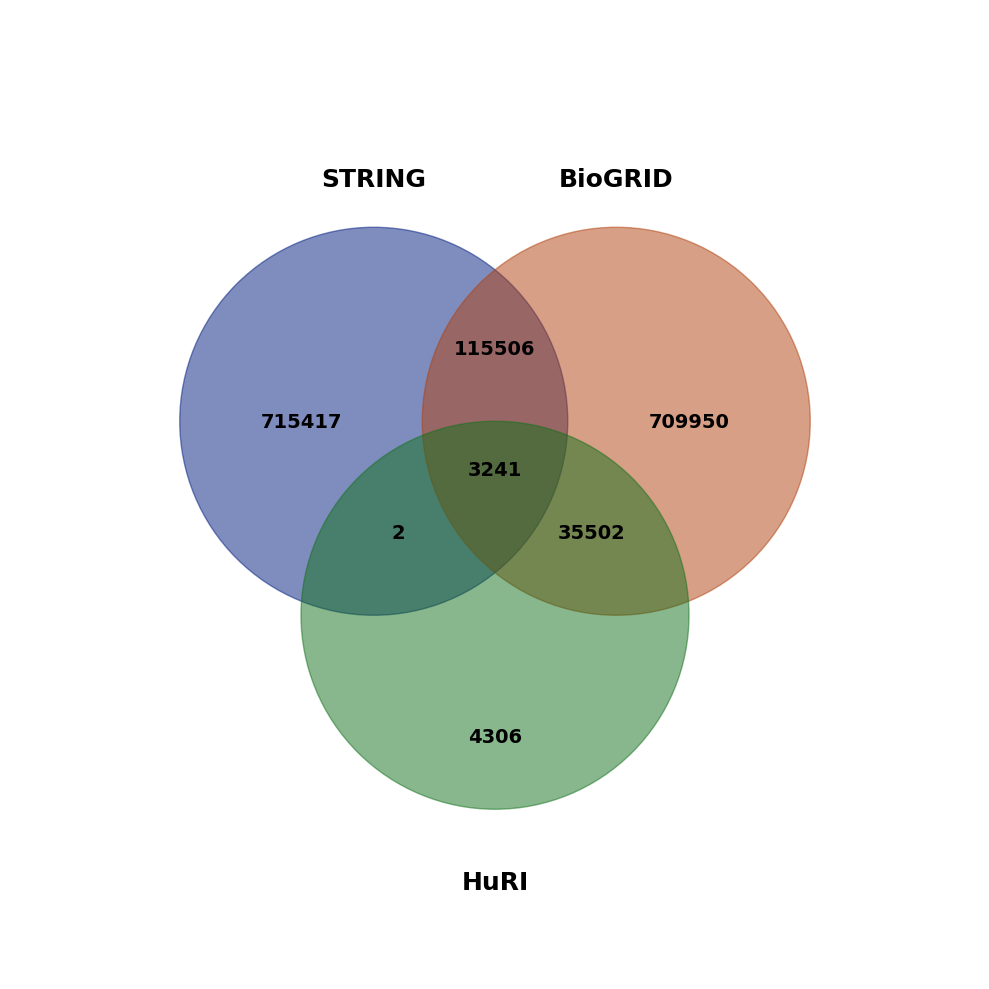

In [14]:
# Create Venn diagram to visualize overlap between the three networks
from matplotlib_venn import venn3_circles
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Source' and create sets of unordered (GeneA, GeneB) pairs
source_groups = PPI_network.groupby('Source').apply(
    lambda x: set(tuple(sorted(pair)) for pair in zip(x['GeneA'], x['GeneB']))
)

# Get the three sets
set1 = source_groups['STRING']
set2 = source_groups['BioGRID_genes']
set3 = source_groups['HuRI']

# Calculate overlap counts
only_string = len(set1 - set2 - set3)
only_biogrid = len(set2 - set1 - set3)
only_huri = len(set3 - set1 - set2)
string_biogrid = len(set1 & set2 - set3)
string_huri = len(set1 & set3 - set2)
biogrid_huri = len(set2 & set3 - set1)
all_three = len(set1 & set2 & set3)

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Define circle positions and radius (all same size)
radius = 0.4
colors = sns.color_palette('dark', 3)

# Create three overlapping circles with equal size
circle1 = Circle((-0.25, 0.15), radius, color=colors[0], alpha=0.5, label='STRING')
circle2 = Circle((0.25, 0.15), radius, color=colors[1], alpha=0.5, label='BioGRID')
circle3 = Circle((0, -0.25), radius, color=colors[2], alpha=0.5, label='HuRI')

ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)

# Add labels for each region with counts (plain black text, no boxes)
# Only STRING (left)
ax.text(-0.4, 0.15, f'{only_string}', 
        fontsize=14, fontweight='bold', ha='center', va='center', color='black')

# Only BioGRID (right)
ax.text(0.4, 0.15, f'{only_biogrid}', 
        fontsize=14, fontweight='bold', ha='center', va='center', color='black')

# Only HuRI (bottom)
ax.text(0, -0.5, f'{only_huri}', 
        fontsize=14, fontweight='bold', ha='center', va='center', color='black')

# STRING & BioGRID overlap (top center)
ax.text(0, 0.3, f'{string_biogrid}', 
        fontsize=14, fontweight='bold', ha='center', va='center', color='black')

# STRING & HuRI overlap (bottom left)
ax.text(-0.2, -0.08, f'{string_huri}', 
        fontsize=14, fontweight='bold', ha='center', va='center', color='black')

# BioGRID & HuRI overlap (bottom right)
ax.text(0.2, -0.08, f'{biogrid_huri}', 
        fontsize=14, fontweight='bold', ha='center', va='center', color='black')

# All three overlap (center)
ax.text(0, 0.05, f'{all_three}', 
        fontsize=14, fontweight='bold', ha='center', va='center', color='black')

# Add database name labels outside circles
ax.text(-0.25, 0.65, 'STRING', fontsize=18, fontweight='bold', ha='center', va='center')
ax.text(0.25, 0.65, 'BioGRID', fontsize=18, fontweight='bold', ha='center', va='center')
ax.text(0, -0.8, 'HuRI', fontsize=18, fontweight='bold', ha='center', va='center')

# Set axis properties
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()

# save figure
plt.savefig(PPI_VENN_FIGURE, dpi=600, bbox_inches='tight', facecolor='white')
print(f'Saved Venn diagram to: {PPI_VENN_FIGURE}')


In [23]:
# Write to csv file
PPI_network.to_csv(PPI_NETWORK_FILE, index=False, sep='\t')
print(f'Saved PPI network to: {PPI_NETWORK_FILE}')

Saved PPI network to: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/PPI_network.tsv


In [24]:
# read PPI network
PPI_network = pd.read_csv(PPI_NETWORK_FILE, sep='\t')
print(PPI_network)

# how many unique interactions not considering 'Source'?
unique_interactions = PPI_network.drop(columns=['Source', 'combined_score']).drop_duplicates()
print(f'The PPI network contains {unique_interactions.shape[0]} unique interactions when not considering the source .')

             GeneA            GeneB  combined_score  Source
0          CYP26B1          ALDH1A2           0.981  STRING
1          CYP26B1          ALDH1A3           0.975  STRING
2          CYP26B1          ALDH1A1           0.962  STRING
3          CYP26B1           CRABP1           0.958  STRING
4          CYP26B1           CYP2B6           0.935  STRING
...            ...              ...             ...     ...
2778343     MRPL12          EXOC3L2             NaN    HuRI
2778344  NOTCH2NLA           MYO15B             NaN    HuRI
2778345     SEC22B  TM4SF19-DYNLT2B             NaN    HuRI
2778346       CCL4             MRM1             NaN    HuRI
2778347     CCL4L2             MRM1             NaN    HuRI

[2778348 rows x 4 columns]
The PPI network contains 2186811 unique interactions when not considering the source .
The PPI network contains 2186811 unique interactions when not considering the source .
